## Reglas de Asocación

Las reglas de asociación se utiliza principalmente para descubrir relaciones interesantes entre variables en grandes conjuntos de datos.
Este método es particularmente efectivo en el análisis de la cesta de la compra, que ayuda a los retailers a comprender las relaciones entre las compras. Al identificar artículos que frecuentemente se compran de manera conjunta. Con ellos las empresas pueden optimizar la colocación de productos y las estrategias de venta cruzada.  
**Conceptos clave:**  
**Soporte (support)**: Indica la frecuencia con la que el conjunto de elementos aparece en el conjunto de datos.  
**Soporte** =Número de transacciones que contienen el conjunto de items(X) / Total de transacciones   
**Confianza** (confidence): Mide la probabilidad de que se compre el artículo Y cuando se compra el artículo X.   
**Elevación (Lift)**: Indica con qué frecuencia se compran juntos los artículos X e Y en comparación con lo que se esperaría si fueran independientes estadísticamente. Lift mayor que 1 indica una asociación positiva  

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth
from mlxtend.frequent_patterns import association_rules
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

#### 0. Importamos los datos

In [2]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\03 Aprendizaje no supervisado'

In [5]:
path = 'data\\GroceryStoreDataSet.csv'
#'C:\\Users\\tomas\\ML\\cluster\\Scripts\\data'

df = pd.read_csv(path,names = ['items'], sep = ',')
df.head(5)
df

,items
0,"MILK,BREAD,BISCUIT"
1,"BREAD,MILK,BISCUIT,CORNFLAKES"
2,"BREAD,TEA,BOURNVITA"
3,"JAM,MAGGI,BREAD,MILK"
4,"MAGGI,TEA,BISCUIT"
5,"BREAD,TEA,BOURNVITA"
6,"MAGGI,TEA,CORNFLAKES"
7,"MAGGI,BREAD,TEA,BISCUIT"
8,"JAM,MAGGI,BREAD,TEA"
9,"BREAD,MILK"


#### 1. Tranformamos los datos

In [6]:
df_1  = df['items'].apply(lambda x : x.split(','))
df_1.head(3)

0                [MILK, BREAD, BISCUIT]
1    [BREAD, MILK, BISCUIT, CORNFLAKES]
2               [BREAD, TEA, BOURNVITA]
Name: items, dtype: object

In [7]:
liste = []

for i in range(len(df_1)):
    x = df_1[i]
    print(x)
    liste.append(x)

['MILK', 'BREAD', 'BISCUIT']
['BREAD', 'MILK', 'BISCUIT', 'CORNFLAKES']
['BREAD', 'TEA', 'BOURNVITA']
['JAM', 'MAGGI', 'BREAD', 'MILK']
['MAGGI', 'TEA', 'BISCUIT']
['BREAD', 'TEA', 'BOURNVITA']
['MAGGI', 'TEA', 'CORNFLAKES']
['MAGGI', 'BREAD', 'TEA', 'BISCUIT']
['JAM', 'MAGGI', 'BREAD', 'TEA']
['BREAD', 'MILK']
['COFFEE', 'CUPCAKE', 'BISCUIT', 'CORNFLAKES']
['COFFEE', 'CUPCAKE', 'BISCUIT', 'CORNFLAKES']
['COFFEE', 'SUGER', 'BOURNVITA']
['BREAD', 'COFFEE', 'CUPCAKE']
['BREAD', 'SUGER', 'BISCUIT']
['COFFEE', 'SUGER', 'CORNFLAKES']
['BREAD', 'SUGER', 'BOURNVITA']
['BREAD', 'COFFEE', 'SUGER']
['BREAD', 'COFFEE', 'SUGER']
['TEA', 'MILK', 'COFFEE', 'CORNFLAKES']


In [9]:
encoder = TransactionEncoder()
pred = encoder.fit_transform(liste)
df = pd.DataFrame(pred,columns = encoder.columns_)
df.head(5)

,BISCUIT,BOURNVITA,BREAD,COFFEE,CORNFLAKES,CUPCAKE,JAM,MAGGI,MILK,SUGER,TEA
0,True,False,True,False,False,False,False,False,True,False,False
1,True,False,True,False,True,False,False,False,True,False,False
2,False,True,True,False,False,False,False,False,False,False,True
3,False,False,True,False,False,False,True,True,True,False,False
4,True,False,False,False,False,False,False,True,False,False,True


In [11]:
pred

array([[ True, False,  True, False, False, False, False, False,  True,
        False, False],
       [ True, False,  True, False,  True, False, False, False,  True,
        False, False],
       [False,  True,  True, False, False, False, False, False, False,
        False,  True],
       [False, False,  True, False, False, False,  True,  True,  True,
        False, False],
       [ True, False, False, False, False, False, False,  True, False,
        False,  True],
       [False,  True,  True, False, False, False, False, False, False,
        False,  True],
       [False, False, False, False,  True, False, False,  True, False,
        False,  True],
       [ True, False,  True, False, False, False, False,  True, False,
        False,  True],
       [False, False,  True, False, False, False,  True,  True, False,
        False,  True],
       [False, False,  True, False, False, False, False, False,  True,
        False, False],
       [ True, False, False,  True,  True,  True, False, Fal

#### 3. A priori

Apriori es un algoritmo para extraer conjuntos de ítems frecuentes con aplicaciones en el aprendizaje de reglas de asociación. El algoritmo Apriori está diseñado para operar en bases de datos que contienen transacciones, como las compras realizadas por los clientes de una tienda. Un conjunto de ítems se considera "frecuente" si cumple con un umbral de soporte especificado por el usuario. Por ejemplo, si el umbral de soporte está en 0.5  quiere decir que estos dos items suceden de manera conjunta en el 50% de los casos.

La función *apriori* espera que los datos estén en un DataFrame de pandas codificado en one-hot. Supongamos que tenemos los siguientes datos de transacciones. Usar el parámetro *colnames = True* hace que se muestren las combinaciones de ítems utilizando sus nombres reales (las etiquetas de las columnas), en lugar de índices o posiciones.

In [12]:
frequency = apriori(df,min_support = 0.15,use_colnames = True,verbose = 1)
frequency

Processing 123 combinations | Sampling itemset size 3


,support,itemsets
0,0.35,(BISCUIT)
1,0.20,(BOURNVITA)
2,0.65,(BREAD)
3,0.40,(COFFEE)
4,0.30,(CORNFLAKES)
5,0.15,(CUPCAKE)
6,0.25,(MAGGI)
7,0.25,(MILK)
8,0.30,(SUGER)
9,0.35,(TEA)


In [13]:
frequency.sort_values('support',ascending = False).head(6)

,support,itemsets
2,0.65,(BREAD)
3,0.40,(COFFEE)
0,0.35,(BISCUIT)
9,0.35,(TEA)
8,0.30,(SUGER)
4,0.30,(CORNFLAKES)


In [14]:
frequency[(frequency['support']>0.50)]

,support,itemsets
2,0.65,(BREAD)


In [108]:
frequency_fp=fpgrowth(df, min_support=0.3, use_colnames=True)
frequency_fp.sort_values('support',ascending = False).head(6)

,support,itemsets
0,0.65,(BREAD)
4,0.40,(COFFEE)
1,0.35,(BISCUIT)
3,0.35,(TEA)
2,0.30,(CORNFLAKES)
5,0.30,(SUGER)


#### 4. Reglas de asociación

La generación de reglas es una tarea común en la minería de patrones frecuentes. Una regla de asociación es una expresión de implicación de la forma X→Y, donde X e Y son conjuntos de ítems disjuntos. Un ejemplo más concreto basado en el comportamiento del consumidor sería {Pañales}→{Cerveza}, lo que sugiere que las personas que compran pañales también tienen probabilidades de comprar cerveza. Para evaluar el "interés" de una regla de asociación como esta, se han desarrollado diferentes métricas. La implementación actual utiliza las métricas de confianza (confidence) y elevación (lift).

#### Soporte

##### Soporte: 
El soporte es una métrica clave en las reglas de asociación que mide la frecuencia con la que ocurre un conjunto de ítems en un conjunto de datos o transacciones. Representa la proporción de transacciones en las que aparece un conjunto de ítems en relación al total de transacciones.

    Soporte =Número de transacciones que contienen el conjunto de items(X) / Total de transacciones

##### Interpretación:
El soporte indica qué tan "popular" o frecuente es un conjunto de ítems en el conjunto de datos.
Valores altos de soporte significan que el conjunto de ítems aparece con frecuencia en las transacciones.
Es importante para identificar los patrones más relevantes dentro de los datos.

#### Lift (Elevación)
Mide la fuerza de la asociación entre X e Y, comparada con lo que esperarías si X e Y fueran independientes (sin relación entre sí).

##### Interpretación:

    Lift = 1: Los ítems X e Y son independientes.
    Lift > 1: Existe una asociación positiva; X e Y tienden a aparecer juntos con más frecuencia de lo esperado.
    Lift < 1: Existe una asociación negativa; X e Y aparecen juntos con menos frecuencia de lo esperado.

#### Confidence (Confianza)
Qué mide: La probabilidad de que un conjunto de ítems (Y) sea comprado o seleccionado, dado que otro conjunto de ítems (X) ya ha sido comprado o seleccionado.

Confianza = Soporte (𝑋∪𝑌) / Soporte(X) 


##### Interpretación: 
Una confianza del 70%, por ejemplo, significa que en el 70% de las ocasiones en las que se compra 𝑋, también se compra 𝑌.

In [15]:
#Seleccionamos aquellas relacciones con un lift superior a 1.3
rules =  association_rules(frequency,metric = 'lift',min_threshold = 0.8)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(BISCUIT),(BREAD),0.35,0.65,0.20,0.571429,0.879121,1.0,-0.0275,0.816667,-0.174603,0.250000,-0.224490,0.439560
1,(BREAD),(BISCUIT),0.65,0.35,0.20,0.307692,0.879121,1.0,-0.0275,0.938889,-0.282051,0.250000,-0.065089,0.439560
2,(CORNFLAKES),(BISCUIT),0.30,0.35,0.15,0.500000,1.428571,1.0,0.0450,1.300000,0.428571,0.300000,0.230769,0.464286
3,(BISCUIT),(CORNFLAKES),0.35,0.30,0.15,0.428571,1.428571,1.0,0.0450,1.225000,0.461538,0.300000,0.183673,0.464286
4,(BOURNVITA),(BREAD),0.20,0.65,0.15,0.750000,1.153846,1.0,0.0200,1.400000,0.166667,0.214286,0.285714,0.490385
5,(BREAD),(BOURNVITA),0.65,0.20,0.15,0.230769,1.153846,1.0,0.0200,1.040000,0.380952,0.214286,0.038462,0.490385
6,(MAGGI),(BREAD),0.25,0.65,0.15,0.600000,0.923077,1.0,-0.0125,0.875000,-0.100000,0.200000,-0.142857,0.415385
7,(BREAD),(MAGGI),0.65,0.25,0.15,0.230769,0.923077,1.0,-0.0125,0.975000,-0.192308,0.200000,-0.025641,0.415385
8,(BREAD),(MILK),0.65,0.25,0.20,0.307692,1.230769,1.0,0.0375,1.083333,0.535714,0.285714,0.076923,0.553846
9,(MILK),(BREAD),0.25,0.65,0.20,0.800000,1.230769,1.0,0.0375,1.750000,0.250000,0.285714,0.428571,0.553846


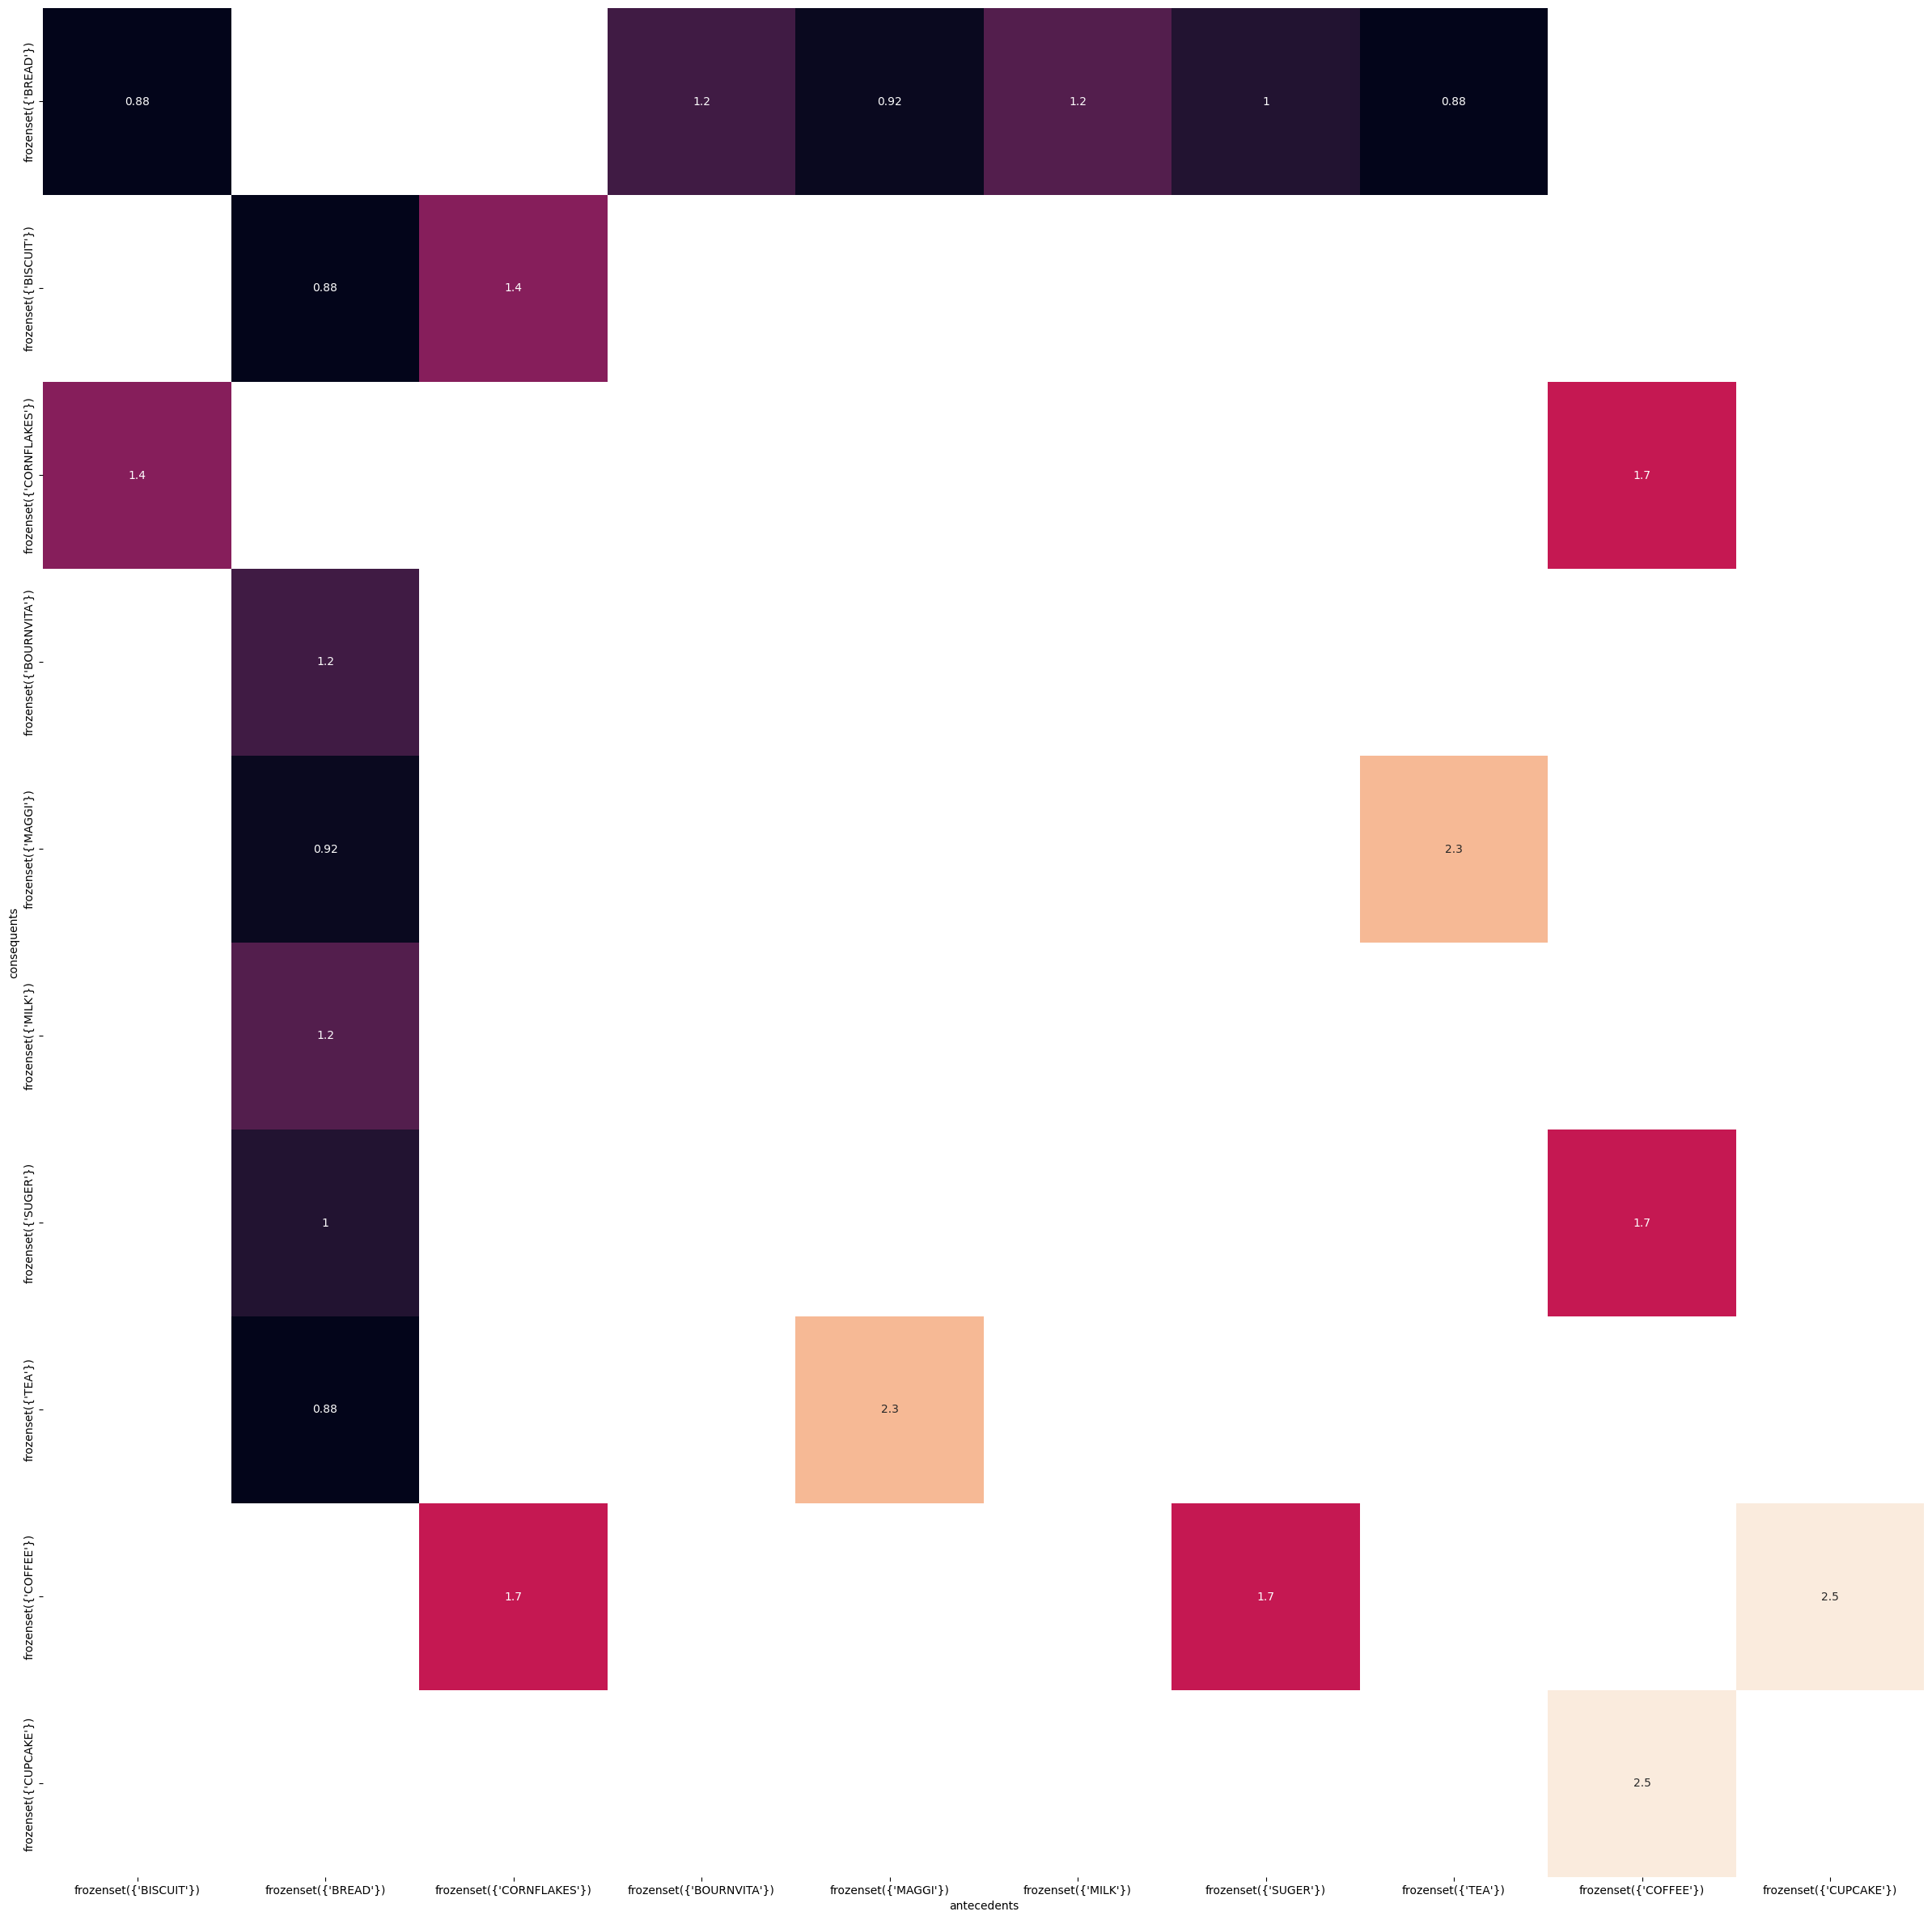

In [16]:
fig, ax = plt.subplots(figsize = (30,30))
pivot = rules.pivot(index = 'consequents', 
                   columns = 'antecedents', values= 'lift')
sns.heatmap(pivot,annot=True,cbar=False,ax = ax)
plt.show()

In [17]:
# de los elementos de antedentes y consecuencias, cuando hay varios seleccionamos el primero
rules['antecedent'] = rules['antecedents'].apply(lambda antecedents : list(antecedents)[0])
rules['consequent'] = rules['consequents'].apply(lambda consequents : list(consequents)[0])
rules['rule'] = rules.index
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,rule
0,(BISCUIT),(BREAD),0.35,0.65,0.20,0.571429,0.879121,1.0,-0.0275,0.816667,-0.174603,0.250000,-0.224490,0.439560,BISCUIT,BREAD,0
1,(BREAD),(BISCUIT),0.65,0.35,0.20,0.307692,0.879121,1.0,-0.0275,0.938889,-0.282051,0.250000,-0.065089,0.439560,BREAD,BISCUIT,1
2,(CORNFLAKES),(BISCUIT),0.30,0.35,0.15,0.500000,1.428571,1.0,0.0450,1.300000,0.428571,0.300000,0.230769,0.464286,CORNFLAKES,BISCUIT,2
3,(BISCUIT),(CORNFLAKES),0.35,0.30,0.15,0.428571,1.428571,1.0,0.0450,1.225000,0.461538,0.300000,0.183673,0.464286,BISCUIT,CORNFLAKES,3
4,(BOURNVITA),(BREAD),0.20,0.65,0.15,0.750000,1.153846,1.0,0.0200,1.400000,0.166667,0.214286,0.285714,0.490385,BOURNVITA,BREAD,4
5,(BREAD),(BOURNVITA),0.65,0.20,0.15,0.230769,1.153846,1.0,0.0200,1.040000,0.380952,0.214286,0.038462,0.490385,BREAD,BOURNVITA,5
6,(MAGGI),(BREAD),0.25,0.65,0.15,0.600000,0.923077,1.0,-0.0125,0.875000,-0.100000,0.200000,-0.142857,0.415385,MAGGI,BREAD,6
7,(BREAD),(MAGGI),0.65,0.25,0.15,0.230769,0.923077,1.0,-0.0125,0.975000,-0.192308,0.200000,-0.025641,0.415385,BREAD,MAGGI,7
8,(BREAD),(MILK),0.65,0.25,0.20,0.307692,1.230769,1.0,0.0375,1.083333,0.535714,0.285714,0.076923,0.553846,BREAD,MILK,8
9,(MILK),(BREAD),0.25,0.65,0.20,0.800000,1.230769,1.0,0.0375,1.750000,0.250000,0.285714,0.428571,0.553846,MILK,BREAD,9


In [18]:
# ordenamos por lift y nos quedamos con las 5 con lift mas alto
rules.sort_values('lift',ascending = False).head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,rule
17,(CUPCAKE),(COFFEE),0.15,0.40,0.15,1.000000,2.500000,1.0,0.0900,inf,0.705882,0.375,1.000000,0.687500,CUPCAKE,COFFEE,17
16,(COFFEE),(CUPCAKE),0.40,0.15,0.15,0.375000,2.500000,1.0,0.0900,1.36,1.000000,0.375,0.264706,0.687500,COFFEE,CUPCAKE,16
20,(TEA),(MAGGI),0.35,0.25,0.20,0.571429,2.285714,1.0,0.1125,1.75,0.865385,0.500,0.428571,0.685714,TEA,MAGGI,20
21,(MAGGI),(TEA),0.25,0.35,0.20,0.800000,2.285714,1.0,0.1125,3.25,0.750000,0.500,0.692308,0.685714,MAGGI,TEA,21
19,(COFFEE),(SUGER),0.40,0.30,0.20,0.500000,1.666667,1.0,0.0800,1.40,0.666667,0.400,0.285714,0.583333,COFFEE,SUGER,19


In [19]:
# ordenamos por confidence y nos quedamos con las 5 con confidence superior
rules.sort_values('confidence',ascending = False).head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,rule
17,(CUPCAKE),(COFFEE),0.15,0.40,0.15,1.000000,2.500000,1.0,0.0900,inf,0.705882,0.375000,1.000000,0.687500,CUPCAKE,COFFEE,17
9,(MILK),(BREAD),0.25,0.65,0.20,0.800000,1.230769,1.0,0.0375,1.75,0.250000,0.285714,0.428571,0.553846,MILK,BREAD,9
21,(MAGGI),(TEA),0.25,0.35,0.20,0.800000,2.285714,1.0,0.1125,3.25,0.750000,0.500000,0.692308,0.685714,MAGGI,TEA,21
4,(BOURNVITA),(BREAD),0.20,0.65,0.15,0.750000,1.153846,1.0,0.0200,1.40,0.166667,0.214286,0.285714,0.490385,BOURNVITA,BREAD,4
10,(SUGER),(BREAD),0.30,0.65,0.20,0.666667,1.025641,1.0,0.0050,1.05,0.035714,0.266667,0.047619,0.487179,SUGER,BREAD,10


In [20]:
# filtramos para quedarnos con aquellos con alta confidence y alto lift
rules[(rules['confidence']>0.79) & (rules['lift'] > 1.65)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,rule
17,(CUPCAKE),(COFFEE),0.15,0.40,0.15,1.0,2.500000,1.0,0.0900,inf,0.705882,0.375,1.000000,0.687500,CUPCAKE,COFFEE,17
21,(MAGGI),(TEA),0.25,0.35,0.20,0.8,2.285714,1.0,0.1125,3.25,0.750000,0.500,0.692308,0.685714,MAGGI,TEA,21


<Axes: >

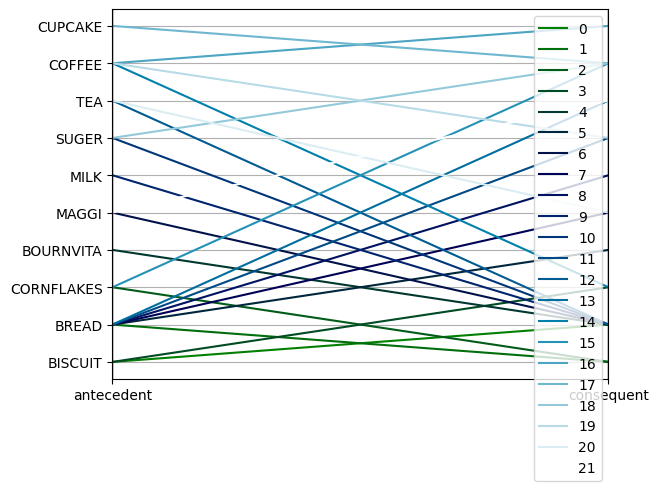

In [21]:
cords = rules[['antecedent','consequent','rule']]

parallel_coordinates(cords,'rule',colormap = 'ocean')

In [22]:
rules[(rules['lift'] < 0.9)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent,consequent,rule
0,(BISCUIT),(BREAD),0.35,0.65,0.2,0.571429,0.879121,1.0,-0.0275,0.816667,-0.174603,0.25,-0.224490,0.43956,BISCUIT,BREAD,0
1,(BREAD),(BISCUIT),0.65,0.35,0.2,0.307692,0.879121,1.0,-0.0275,0.938889,-0.282051,0.25,-0.065089,0.43956,BREAD,BISCUIT,1
12,(TEA),(BREAD),0.35,0.65,0.2,0.571429,0.879121,1.0,-0.0275,0.816667,-0.174603,0.25,-0.224490,0.43956,TEA,BREAD,12
13,(BREAD),(TEA),0.65,0.35,0.2,0.307692,0.879121,1.0,-0.0275,0.938889,-0.282051,0.25,-0.065089,0.43956,BREAD,TEA,13
